<a href="https://colab.research.google.com/github/honuboy/PSY360/blob/main/Homework_Categorization_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework - Categorization and Model Comparison Part B (35/105 points)

PSY/COS 360, Computational Models of Cognition, Fall 2026.

Credit for first version and for the categorization data: Prof. Todd Gureckis at New York University.

<div style="background-color: #eef2f6; color: #1f2933; border-left: 4px solid #7b8a97; padding: 12px 16px; border-radius: 4px;">

<p style="margin-top: 0;">Parts of your code are checked by an automated grader. For the grader to work, please keep the following in mind as you complete the assignment:</p>

<ul style="margin-bottom: 0;">
<li><b>Do not rename this notebook file or any of the starter functions we provide.</b> The grader looks for them by name, so a renamed file or function will fail even if the code is correct.</li>
<li><b>Make sure the notebook runs from top to bottom without errors.</b> Before submitting, choose <code>Restart</code>, <code>Clear All Outputs</code>, and then <code>Run All</code> from the notebook menu. Confirm that every cell executes in order and produces the expected output.</li>
<li><b>Do NOT clear the output when submitting.</b> Submit the notebook with the output of each cell. The grader may use these values.</li>
</ul>
</div>


---

In [21]:
!git clone https://github.com/brendenlake/CMC2026.git
%cd CMC2026/homeworks/homework-Categorization

Cloning into 'CMC2026'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 89 (delta 27), reused 67 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 865.39 KiB | 21.11 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/CMC2026/homeworks/homework-Categorization/CMC2026/homeworks/homework-Categorization


In [22]:
!pip install -r requirements.txt

In [23]:
import seaborn as sns
import pandas as pd
import math
from scipy.special import comb  # gets the combinations function
from exemplarproto import *  # this grabs much of the code from Part A of the homework
# note that , Part B runs the frozen copy in exemplarproto.py, not your edited Part A cells

import os
import numpy as np
from scipy.optimize import fmin

## Fitting the models using maximum likelihood

RMSE is not always an ideal mechanism for fitting models.  One reason is that it is insensitive to the number of observations that define each data point.  For example, remember in our experiment that participants saw the prototype item four times at test.  In contrast, there were 20 different "new" patterns.  This means there are five times as many trials contributing to the "new" bar in this graph as for the prototype patterns.  Since RMSE measures the raw deviation of the average model predictions from those of the model it doesn't take into account these issues.  Thus, we would like to also evaluate these two models using maximum likelihood.

The key to this is going to be the provided function below which computes the likelihood of a particular set of data under a binomial probability model. Again, this uses the Pandas library, with a [short introduction here](https://pandas.pydata.org/docs/user_guide/10min.html) and an explanation of the [.groupby](https://pandas.pydata.org/docs/user_guide/groupby.html) routine.

In [24]:
################################
# computeLogLikelihood
# N = number of observations
# S = number of "successes" (i.e., endorsements)
# p = predicted probability of successes by the model
################################
def computeLogLikelihood(N, S, p):
    p = p if p > 0.0 else 0.0+1e-10
    p = p if p < 1.0 else 1.0-1e-10
    try:
        result = math.log(comb(N, S)) + (S*math.log(p) + (N-S)*math.log(1.0-p)) # log binomial likelihood
    except:
        print(N, S, p)  # this shouldn't happen but just in case
        result = float('-inf')
    return result


def pandas_ll(row):
    return computeLogLikelihood(row['Total'], row['N_Yes'], row['Probability of Endorsement'])

A short explanation may be in order: the models predictions take the form of probabilities of endorsement for each of the prototype, low, high, random, and old items. If you find out that people endorse the prototype on 2 out of 2 trials how likely is this outcome given that the model (for a particular set of parameters ) predicts an endorsement of p=0.8? Three numbers are required to do this for each data point N, the number of trials/presentations within the stimulus class, S the number of successes observed (S<=N), and p the predicted probability. Then you can turn the crank on the above `computeLogLikelihood()` function which returns the probability that you would get $S$ successes in $N$ trials if the true probability was $p$ (make sure you understand what is happening in `computeLogLikelihood`). You can sum these log likelihoods for each stimulus class (prototype, low, high, random, old) to compute a total log(likelihood) of the data for any given model with any set of parameters.   For this homework will we focus on fitting the group data rather than to individuals.

To get the data formatted into an appropriate shape for fitting likelihoods we provide a function `get_human_results_ll()` which returns a Pandas data frame containing the number of times a pattern of a particular type was endorsed and the number of times it was presented for each subject.

In [25]:
human_res=get_human_results_ll()
human_res

,Subject,Condition,Stimulus Type,N_Yes,Total
0,./data/2.dat,cat,Prototype,3,4
1,./data/2.dat,cat,Low,3,4
2,./data/2.dat,cat,High,5,10
3,./data/2.dat,cat,Random,1,20
4,./data/2.dat,cat,Old,8,20
...,...,...,...,...,...
0,./data/5.dat,rec,Prototype,2,4
1,./data/5.dat,rec,Low,0,4
2,./data/5.dat,rec,High,3,10
3,./data/5.dat,rec,Random,1,20


This reorganizes the data per condition.

In [26]:
human_data=human_res.groupby(['Condition','Stimulus Type']).sum(numeric_only=True)
human_data

N_Yes  Total
Condition Stimulus Type              
cat       High              49     70
          Low               26     28
          Old              110    140
          Prototype         25     28
          Random            37    140
rec       High              20     70
          Low               16     28
          Old               89    140
          Prototype         18     28
          Random             7    140

Finally these function allow us to compute the negative log likelihood of the data given the model.

In [27]:
def fit_exemplar_model_nll(params, human_results):
    [c_cat, k_cat, c_rec, k_rec] = params
    k_cat = k_cat if k_cat > 0.0 else 0.0
    k_rec = k_rec if k_rec > 0.0 else 0.0
    predictions = get_exemplar_results(c_cat, k_cat, c_rec, k_rec)
    model = predictions.groupby(
        ['Condition', 'Stimulus Type'], as_index=False).mean(numeric_only=True)
    fitted_data = pd.merge(model, human_results)
    return -1.0*fitted_data.apply(pandas_ll, axis=1).sum()


def fit_prototype_model_nll(params, human_results):
    [c_cat, k_cat, c_rec, k_rec] = params
    k_cat = k_cat if k_cat > 0.0 else 0.0
    k_rec = k_rec if k_rec > 0.0 else 0.0
    predictions = get_prototype_results(c_cat, k_cat, c_rec, k_rec)
    model = predictions.groupby(
        ['Condition', 'Stimulus Type'], as_index=False).mean(numeric_only=True)
    fitted_data = pd.merge(model, human_results)
    return -1.0*fitted_data.apply(pandas_ll, axis=1).sum()

<div class="alert alert-success" role="alert">
<h3> Problem 6 (20 points) </h3><br>
The cell blocks below allow you to fit the exemplare model and the prototype model to the dataset we considered in Part A of the homework. Make sure you understand and follow the code provided above and in the provided library (exemplarproto.py).  

Next, try altering the parameters to minimize the negative log likelihood score using the `fmin` approach form Part 1.  When you think you have found the best fit parameters for both the exemplar and prototype models report your final parameter values along with the plot of the resulting model predictions.

In a markdown cell describe which model you believe fits better.  Is this conclusion the same or different from what you considered with RMSE?  If the fit looks different, why?
</div>

In [28]:
human_res_ll = get_human_results_ll()
human_data_for_nll = human_res_ll.groupby(['Condition', 'Stimulus Type']).sum(numeric_only=True).reset_index()

exemplar_start = [2.1, 0.09, 2.08, 0.55]
param_opt_exemplar, nll_exemplar, *_ = fmin(fit_exemplar_model_nll, exemplar_start, args=(human_data_for_nll,), full_output=True)

prototype_start = [1.4, 0.045, 1.35, 0.195]
param_opt_prototype, nll_prototype, *_ = fmin(fit_prototype_model_nll, prototype_start, args=(human_data_for_nll,), full_output=True)

print('Optimal exemplar model:', param_opt_exemplar)
print('Optimal prototype model:', param_opt_prototype)

print('The NLL for the exemplar model is: ', nll_exemplar)
print('The NLL for the prototype model is: ', nll_prototype)

Optimization terminated successfully.
         Current function value: 28.268922
         Iterations: 122
         Function evaluations: 211
Optimization terminated successfully.
         Current function value: 32.246756
         Iterations: 96
         Function evaluations: 168
Optimal exemplar model: [1.48768752 0.35960582 1.93040344 0.78400384]
Optimal prototype model: [1.5881996  0.03164431 1.87906965 0.08401808]
The NLL for the exemplar model is:  28.268922072553075
The NLL for the prototype model is:  32.246756084950235


Best fit parameters:

Prototype: [1.59  0.032 1.88 0.08]

Exemplar: [1.49 0.36 1.93 0.78]

Which one seems to fit better?

Based strictly on the NLL, the exemplar model seems to fit best.

Both feel quite similar visually comparing the human to optimized graphs, though I will point out that the difference between cat and rec in the exemplar model is more pronounced and better mimics the human results. In part A the exemplar model did better by 0.9%, so I guess it agrees, but that's a pretty small margin.



**Exemplar model**

The negative log score is 28.26892207256839


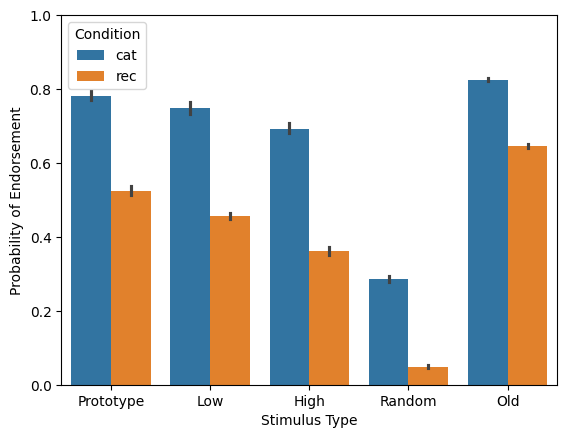

In [29]:
human = human_res.groupby(['Condition', 'Stimulus Type'], as_index=False).sum(numeric_only=True)

params = [1.48768752, 0.35960582, 1.93040344, 0.78400384]
nllfit = fit_exemplar_model_nll(params, human)
print(f'The negative log score is {nllfit}')

# now plot the data
c_cat, k_cat, c_rec, k_rec = params
res = get_exemplar_results(c_cat, k_cat, c_rec, k_rec)
ax = sns.barplot(x="Stimulus Type", y="Probability of Endorsement",
            hue="Condition", data=res)
ax.set_ylim(0, 1.0);

**Prototype Model**

The negative log score is 32.2467560850051


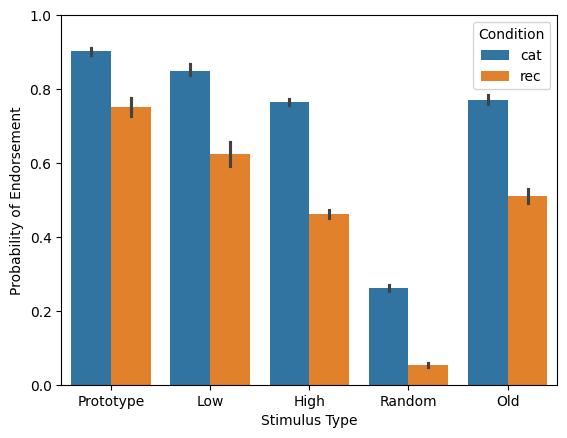

In [30]:
human = human_res.groupby(['Condition', 'Stimulus Type'], as_index=False).sum(numeric_only=True)

params = [1.5881996, 0.03164431, 1.87906965, 0.08401808]
nllfit = fit_prototype_model_nll(params, human)
print(f'The negative log score is {nllfit}')

# now plot the data
c_cat, k_cat, c_rec, k_rec = params
res = get_prototype_results(c_cat, k_cat, c_rec, k_rec)
ax = sns.barplot(x="Stimulus Type", y="Probability of Endorsement",
            hue="Condition", data=res)
ax.set_ylim(0, 1.0);

**Human data again for reference**

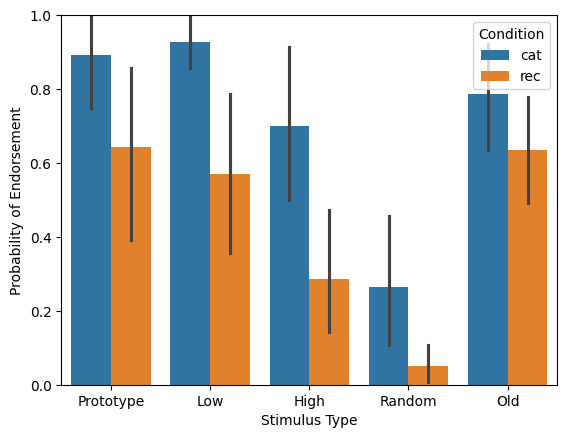

In [31]:
ax = sns.barplot(x="Stimulus Type", y="Probability of Endorsement",
            hue="Condition", data=get_human_results())
ax.set_ylim(0, 1.0);

<div class="alert alert-success" role="alert">
<h3> Problem 7 (10 points) </h3><br>
A famous saying is the "All models are wrong, but some are useful" (George Box).  Do you think the exemplar or prototype model provides the best account of the data?  Refer to particular patterns in the data that you believe the different models do a better job with.
</div>

I'd maybe make the claim that the prototype model better suits the cats while the exemplar model better suits the recs. In the human results, the Prototype and Low groups are pretty high for cat, which is matched by the prototype model.

<div class="alert alert-success" role="alert">
<h3> Problem 8 (5 points) </h3><br>

Thinking about how these models work explain why both the exemplar and prototype models have relatively high endorsement for the prototype item even though it was never presented during the training phase.  In addition, explain in your own words why the models are able to explain the high endorsement rates for the old items.
    
</div>

Exemplar: This model compares all previous memories to the presented item (prototype for this case). Because we can expect the distances between prototype points and training data points to be relatively low on average, it makes sense that the prototype is endorsed successfully.

Prototype: This model averages all the items previously presented in training. Because teh training data is just some deviation of the prototype, we would expect the average to tend towards the prototype as the number of samples increases, so it really makes sense that the prototype model endorses the prototype.